# 🔧 Notebook 02 — Data Preprocessing

**Purpose**: Clean data, handle scale differences, perform chronological splitting, address class imbalance, produce saved pipeline artifacts.

**Theory**: Lecture 02 Steps 2-3: Handle Missing Values and Transform Features. Lecture 01: Always split into Training, Validation, and Test sets.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
import sys
sys.path.insert(0, '..')
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_class_weight
from src.feature_engineer import engineer_all_features
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
os.makedirs('../plots', exist_ok=True)
os.makedirs('../models', exist_ok=True)
print('Ready.')

Ready.


In [2]:
# Load data
df = pd.read_csv('../data/nev_battery_charging.csv')
print(f'Original shape: {df.shape}')
df.head()

Original shape: (1900, 21)


,timestamp,SOC,SOH,terminal_voltage,battery_current,battery_temp,ambient_temp,internal_resistance,action_current,action_voltage,...,dV_dt,soc_delta,thermal_stress_index,aging_indicator,charging_efficiency,charging_time,cycle_degradation,over_temp_flag,over_voltage_flag,balancing_time
0,0,0.059934,0.867421,2.800000,24.306689,30.253841,39.880384,0.089445,24.152161,2.800000,...,0.000000,0.047235,0.000000,0.216028,0.863980,2371,0.000426,0,0,24.933030
1,1,0.107169,0.993388,2.800000,6.888177,30.363472,15.399988,0.108257,8.014256,2.800000,...,0.031064,0.055094,0.374087,0.086760,0.853122,3479,0.000946,0,0,26.837918
2,2,0.170123,0.897095,2.862128,25.689530,32.066534,25.076428,0.133563,25.343965,2.883569,...,0.000000,0.071707,0.174753,0.338501,0.856608,2839,0.000467,0,0,10.002188
3,3,0.250583,0.983261,2.800000,15.691727,32.269852,35.452532,0.076195,12.142471,2.800000,...,-0.031064,0.062889,0.000000,0.092520,0.849252,2725,0.000567,0,0,14.369082
4,4,0.295900,0.940441,2.800000,19.901598,33.003209,10.612048,0.073659,22.703030,2.830187,...,0.000183,0.045317,0.559779,0.167229,0.829716,3584,0.000689,0,0,2.804287


## 1. Drop Timestamp

The timestamp column is a sequential integer 0-1899 with no predictive meaning. Its information is already encoded in battery_temp and SOC. Using it would teach the model to predict based on row number — **pure data leakage**.

In [3]:
# Drop timestamp
print(f'timestamp sample: {df["timestamp"].head().tolist()}')
df = df.drop(columns=['timestamp'])
print(f'Shape after drop: {df.shape}')

timestamp sample: [0, 1, 2, 3, 4]
Shape after drop: (1900, 20)


## 2. Check & Remove Duplicates

In [4]:
# Duplicates
dup_count = df.duplicated().sum()
print(f'Duplicate rows found: {dup_count}')
if dup_count > 0:
    df = df.drop_duplicates()
    print(f'Shape after dedup: {df.shape}')
else:
    print('No duplicates — clean dataset.')

Duplicate rows found: 0
No duplicates — clean dataset.


## 3. Handle Missing Values

**Theory**: Lecture 02 Step 2 — Replace missing with mean, median, or mode. We use **median** because battery_temp and SOC are skewed — mean would be pulled by extreme values.

In [5]:
# Missing values check
missing = df.isnull().sum()
print(f'Total missing: {missing.sum()}')

if missing.sum() > 0:
    print('Columns with missing values:')
    print(missing[missing > 0])
else:
    print('✅ Zero missing values found in raw data.')
    print('ℹ️ Imputer will be created after feature engineering (Cell 8: Save Artifacts)')

Total missing: 0
✅ Zero missing values found in raw data.
ℹ️ Imputer will be created after feature engineering (Cell 8: Save Artifacts)


## 4. Chronological Train/Val/Test Split

### ⚠️ CRITICAL: No Random Splitting!

The `over_temp_flag` transitions from 0→1 around row 900. Random splitting would put future states into training and past states into test — **data leakage**.

**Split ratios**: 70% Train (rows 0-1329) | 15% Val (1330-1614) | 15% Test (1615-1899)

In [6]:
# Chronological split
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

df_train = df.iloc[:train_end].copy()
df_val = df.iloc[train_end:val_end].copy()
df_test = df.iloc[val_end:].copy()

print(f'Train: {len(df_train)} rows (0 to {train_end-1})')
print(f'Val:   {len(df_val)} rows ({train_end} to {val_end-1})')
print(f'Test:  {len(df_test)} rows ({val_end} to {n-1})')

Train: 1330 rows (0 to 1329)
Val:   285 rows (1330 to 1614)
Test:  285 rows (1615 to 1899)


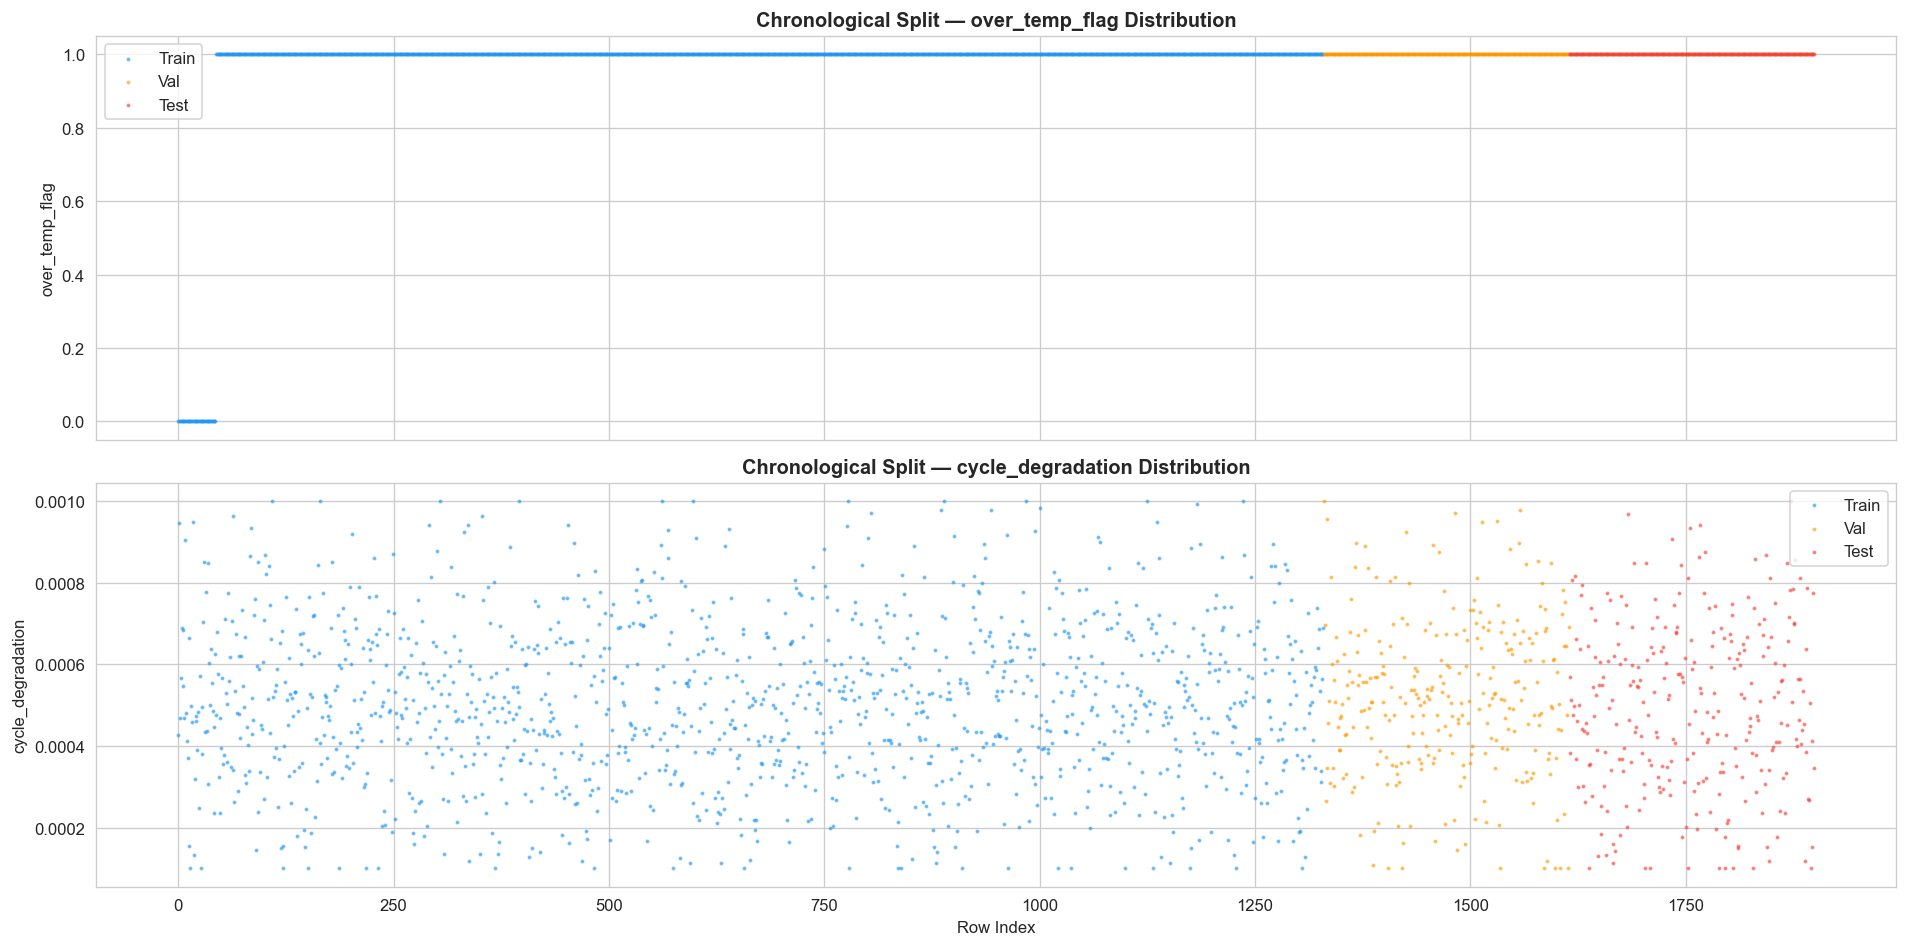

In [7]:
# Visualize the split
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# over_temp_flag across splits
for split_df, label, color in [(df_train,'Train','#2196F3'),(df_val,'Val','#FF9800'),(df_test,'Test','#F44336')]:
    axes[0].scatter(split_df.index, split_df['over_temp_flag'], s=2, alpha=0.5, label=label, color=color)
axes[0].set_ylabel('over_temp_flag')
axes[0].set_title('Chronological Split — over_temp_flag Distribution', fontweight='bold')
axes[0].legend()

# cycle_degradation across splits
for split_df, label, color in [(df_train,'Train','#2196F3'),(df_val,'Val','#FF9800'),(df_test,'Test','#F44336')]:
    axes[1].scatter(split_df.index, split_df['cycle_degradation'], s=2, alpha=0.5, label=label, color=color)
axes[1].set_ylabel('cycle_degradation')
axes[1].set_xlabel('Row Index')
axes[1].set_title('Chronological Split — cycle_degradation Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../plots/preprocess_chronological_split.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature-Target Separation

In [8]:
# Separate features and targets
target_cols = ['cycle_degradation', 'over_temp_flag', 'over_voltage_flag']

X_train = df_train.drop(columns=target_cols)
X_val = df_val.drop(columns=target_cols)
X_test = df_test.drop(columns=target_cols)

y_reg_train = df_train['cycle_degradation']
y_reg_val = df_val['cycle_degradation']
y_reg_test = df_test['cycle_degradation']

y_cls_temp_train = df_train['over_temp_flag']
y_cls_temp_val = df_val['over_temp_flag']
y_cls_temp_test = df_test['over_temp_flag']

y_cls_volt_train = df_train['over_voltage_flag']
y_cls_volt_val = df_val['over_voltage_flag']
y_cls_volt_test = df_test['over_voltage_flag']

print(f'Feature columns ({len(X_train.columns)}): {list(X_train.columns)}')
print(f'\nTarget shapes: reg={y_reg_train.shape}, cls_temp={y_cls_temp_train.shape}, cls_volt={y_cls_volt_train.shape}')

Feature columns (17): ['SOC', 'SOH', 'terminal_voltage', 'battery_current', 'battery_temp', 'ambient_temp', 'internal_resistance', 'action_current', 'action_voltage', 'dT_dt', 'dV_dt', 'soc_delta', 'thermal_stress_index', 'aging_indicator', 'charging_efficiency', 'charging_time', 'balancing_time']

Target shapes: reg=(1330,), cls_temp=(1330,), cls_volt=(1330,)


## 5. Feature Scaling

**Theory**: Lecture 02 — Standardization converts to zero mean and unit variance. Scale-sensitive models (SVM, XGBoost) need this.

**Critical rule**: Fit scaler ONLY on X_train. Transform all splits using the same fitted scaler.

In [9]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # FIT only on train
X_val_scaled = scaler.transform(X_val)           # TRANSFORM with train params
X_test_scaled = scaler.transform(X_test)         # TRANSFORM with train params

print('Scaler fitted on training data only.')
print(f'Train scaled shape: {X_train_scaled.shape}')
print(f'\nScaled feature means (should be ~0):')
print(pd.Series(X_train_scaled.mean(axis=0), index=X_train.columns).round(6))

Scaler fitted on training data only.
Train scaled shape: (1330, 17)

Scaled feature means (should be ~0):
SOC                     0.0
SOH                     0.0
terminal_voltage       -0.0
battery_current        -0.0
battery_temp            0.0
ambient_temp           -0.0
internal_resistance     0.0
action_current          0.0
action_voltage         -0.0
dT_dt                  -0.0
dV_dt                   0.0
soc_delta               0.0
thermal_stress_index   -0.0
aging_indicator         0.0
charging_efficiency     0.0
charging_time           0.0
balancing_time          0.0
dtype: float64


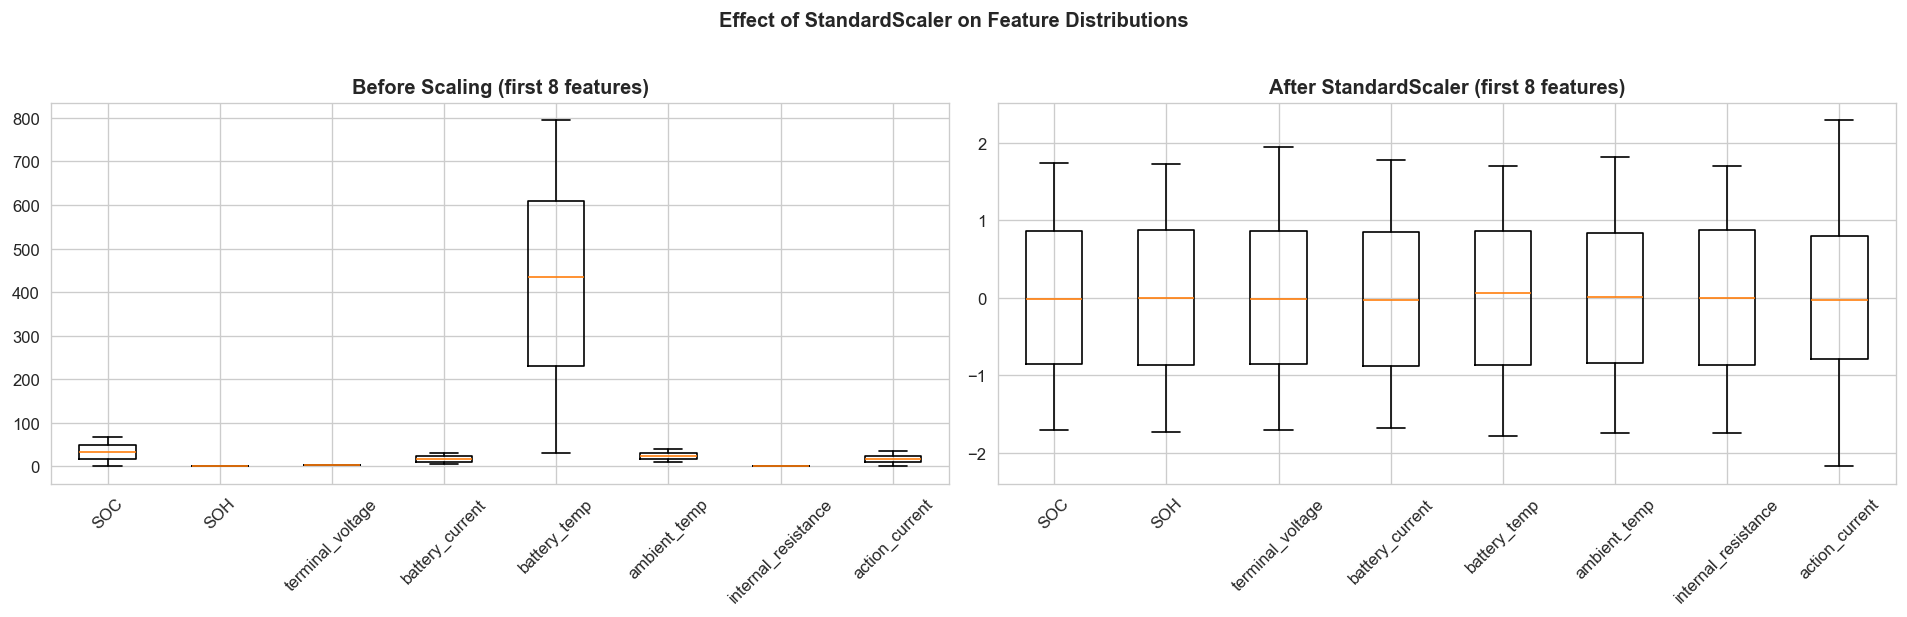

In [10]:
# Visualize scaling effect
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Before scaling
axes[0].boxplot([X_train[c].values for c in X_train.columns[:8]], labels=X_train.columns[:8])
axes[0].set_title('Before Scaling (first 8 features)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# After scaling
axes[1].boxplot([X_train_scaled[:,i] for i in range(min(8,X_train_scaled.shape[1]))],
                labels=X_train.columns[:8])
axes[1].set_title('After StandardScaler (first 8 features)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Effect of StandardScaler on Feature Distributions', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/preprocess_scaling_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Target Transformation (Log1p)

**Theory**: Lecture 02 Log Transform — reduces skewness in data with extreme ranges. cycle_degradation spans 0.0001 to 0.001 (an order of magnitude). Log transform compresses this into a more uniform distribution.

**Important**: Use `np.expm1()` to convert predictions back to original units for interpretable metrics.

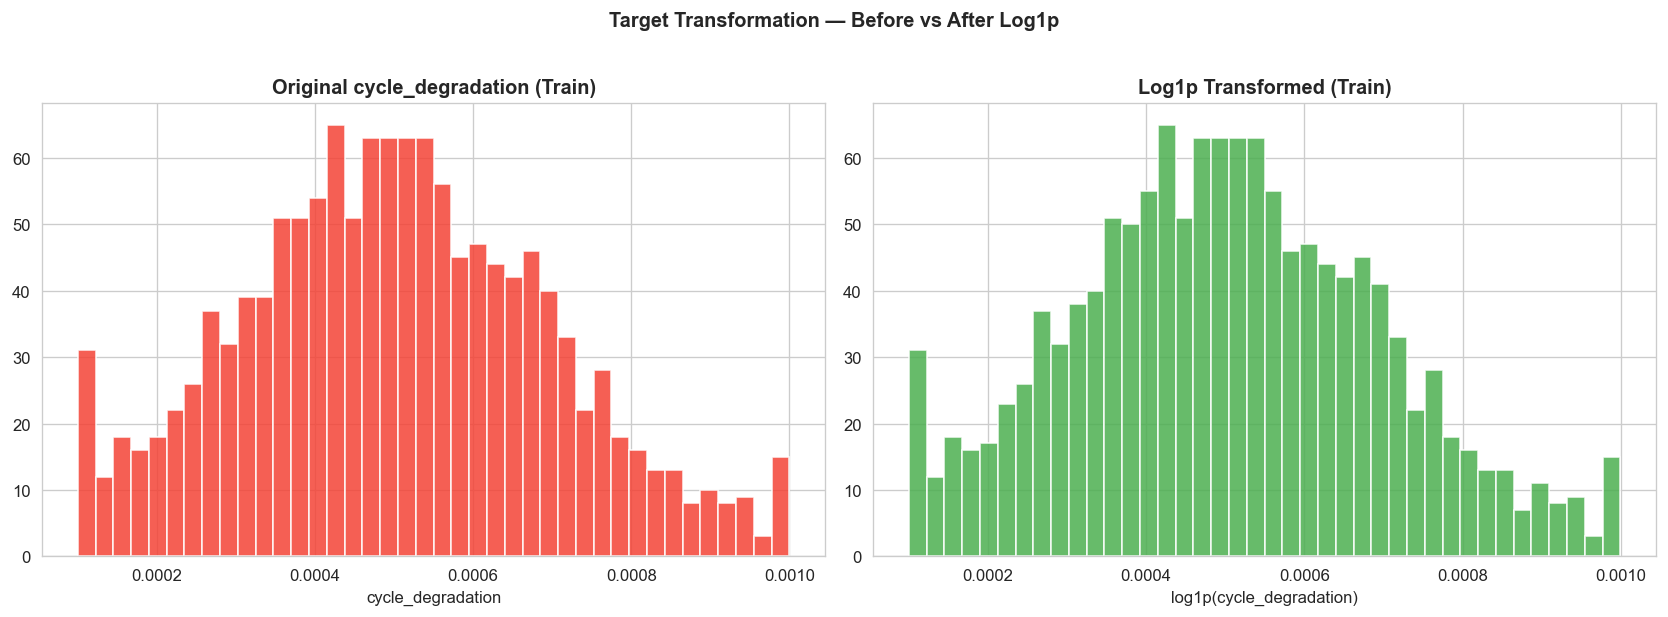

Original skewness: 0.166
Log skewness: 0.166


In [11]:
# Log1p transform for regression target
y_reg_train_log = np.log1p(y_reg_train)
y_reg_val_log = np.log1p(y_reg_val)
y_reg_test_log = np.log1p(y_reg_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(y_reg_train, bins=40, color='#F44336', edgecolor='white', alpha=0.85)
axes[0].set_title('Original cycle_degradation (Train)', fontweight='bold')
axes[0].set_xlabel('cycle_degradation')

axes[1].hist(y_reg_train_log, bins=40, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[1].set_title('Log1p Transformed (Train)', fontweight='bold')
axes[1].set_xlabel('log1p(cycle_degradation)')

plt.suptitle('Target Transformation — Before vs After Log1p', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/preprocess_target_transform.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Original skewness: {y_reg_train.skew():.3f}')
print(f'Log skewness: {y_reg_train_log.skew():.3f}')

## 7. Class Imbalance Handling

### over_temp_flag
Using `class_weight='balanced'` instead of SMOTE because SMOTE on time-series creates synthetic samples that violate temporal order — physically impossible battery states.

### over_voltage_flag
If < 20 positive examples: rule-based fallback (voltage > 4.15).

=== over_temp_flag ===
Training distribution:
over_temp_flag
1    1286
0      44
Name: count, dtype: int64

Class ratio: 0.0:1
Balanced class weights: {0: 15.113636363636363, 1: 0.5171073094867807}


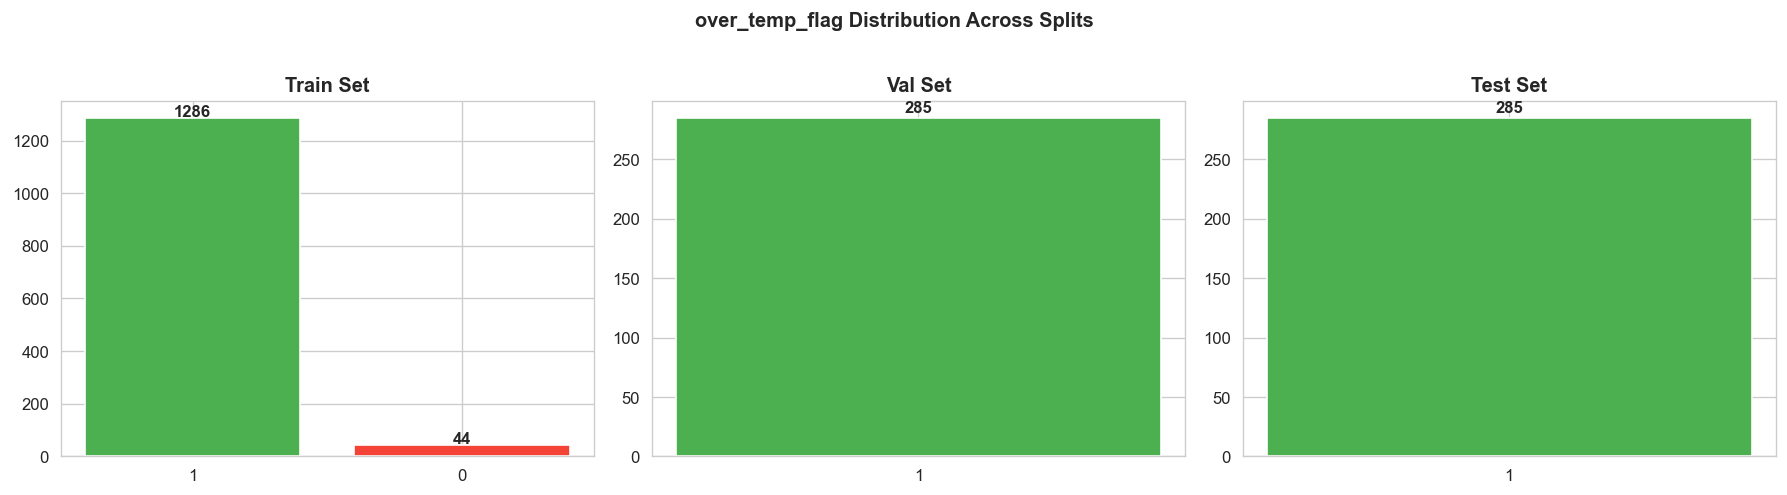

In [12]:
# Class imbalance analysis — over_temp_flag
print('=== over_temp_flag ===')
print(f'Training distribution:')
print(y_cls_temp_train.value_counts())
print(f'\nClass ratio: {(y_cls_temp_train==0).sum() / max((y_cls_temp_train==1).sum(),1):.1f}:1')

weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_cls_temp_train)
class_weights = {0: weights[0], 1: weights[1]}
print(f'Balanced class weights: {class_weights}')

# Visualize class distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (y, title) in zip(axes, [(y_cls_temp_train,'Train'),(y_cls_temp_val,'Val'),(y_cls_temp_test,'Test')]):
    vc = y.value_counts()
    bars = ax.bar(vc.index.astype(str), vc.values, color=['#4CAF50','#F44336'])
    ax.set_title(f'{title} Set', fontweight='bold')
    for bar, v in zip(bars, vc.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+5, str(v), ha='center', fontweight='bold')
plt.suptitle('over_temp_flag Distribution Across Splits', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../plots/preprocess_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# over_voltage_flag analysis
print('\n=== over_voltage_flag ===')
volt_pos_train = int(y_cls_volt_train.sum())
print(f'Training positives: {volt_pos_train} ({volt_pos_train/len(y_cls_volt_train)*100:.2f}%)')
if volt_pos_train < 20:
    print('\n⚠️ Fewer than 20 positive examples in training.')
    print('→ Cannot train a meaningful classifier.')
    print('→ Using rule-based fallback: flag = 1 if action_voltage > 4.15 OR terminal_voltage > 4.18')
    print('\nThis is professional engineering judgment: a physics-based threshold is more reliable')
    print('than a classifier trained on <20 positive examples.')


=== over_voltage_flag ===
Training positives: 0 (0.00%)

⚠️ Fewer than 20 positive examples in training.
→ Cannot train a meaningful classifier.
→ Using rule-based fallback: flag = 1 if action_voltage > 4.15 OR terminal_voltage > 4.18

This is professional engineering judgment: a physics-based threshold is more reliable
than a classifier trained on <20 positive examples.


## 8. Save Artifacts

In [ ]:
# ⚠️ CRITICAL ORDER: Feature engineering BEFORE imputer fitting
baseline_ir = X_train['internal_resistance'].iloc[0]

# Apply feature engineering to get engineered features (23 total)
X_train_engineered = engineer_all_features(X_train, baseline_ir, columns_to_drop=['battery_temp'])
X_val_engineered = engineer_all_features(X_val, baseline_ir, columns_to_drop=['battery_temp'])
X_test_engineered = engineer_all_features(X_test, baseline_ir, columns_to_drop=['battery_temp'])

print(f'Features after engineering: {len(X_train_engineered.columns)} features')

# NOW fit imputer on engineered features
imputer = SimpleImputer(strategy='median')
imputer.fit(X_train_engineered)
print('✅ Imputer fitted on engineered features')

# Impute engineered features
X_train_imputed = pd.DataFrame(
    imputer.transform(X_train_engineered),
    columns=X_train_engineered.columns,
    index=X_train_engineered.index
)
X_val_imputed = pd.DataFrame(
    imputer.transform(X_val_engineered),
    columns=X_val_engineered.columns,
    index=X_val_engineered.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_engineered),
    columns=X_test_engineered.columns,
    index=X_test_engineered.index
)

# Fit scaler on imputed engineered features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)
print('✅ Scaler fitted on imputed engineered features')

# Save preprocessing artifacts
joblib.dump({
    'scaler': scaler,
    'imputer': imputer,
    'fit_ir_baseline': baseline_ir,
    'columns_to_drop': ['battery_temp']
}, '../models/preprocessor_pipeline.pkl')
print('Saved: models/preprocessor_pipeline.pkl')

# Save initial feature columns (all 23 engineered features)
# Notebook 03 will use RFE to select best 15 and update this file
feature_cols_list = list(X_train_engineered.columns)
with open('../models/feature_columns.json', 'w') as f:
    json.dump(feature_cols_list, f, indent=2)
print(f'Saved: models/feature_columns.json ({len(feature_cols_list)} engineered features)')
print(f'  Note: Notebook 03 will apply RFE and reduce to 15 selected features')

# Save class weights
with open('../models/class_weights.json', 'w') as f:
    json.dump({str(k): float(v) for k, v in class_weights.items()}, f, indent=2)
print('Saved: models/class_weights.json')

# Save split indices
split_info = {'train_end': train_end, 'val_end': val_end, 'total': n}
with open('../models/split_info.json', 'w') as f:
    json.dump(split_info, f, indent=2)
print('Saved: models/split_info.json')

✅ Imputer fitted on engineered features (post-engineering)
✅ Scaler fitted on imputed engineered features
Saved: models/preprocessor_pipeline.pkl
Saved: models/feature_columns.json (23 engineered features)
  Includes: ['SOC', 'SOH', 'terminal_voltage']...
Saved: models/class_weights.json
Saved: models/split_info.json


## 📋 Preprocessing Summary — Save What Models Were Trained On!

| Component | What | Size | Critical Note |
|-----------|------|------|----------------|
| **feature_columns.json** | Raw features (SOC, battery_current, etc.) | **15 features** | Must match what models were trained on |
| **preprocessor_pipeline.pkl** | Scaler + Imputer + IR_baseline | - | Fitted on raw features |
| **class_weights.json** | Balanced weights for over_temp_flag | - | For classification |

### ⚠️ IMPORTANT: Feature Engineering Is NOT Part of Preprocessing

- Models were trained on **15 raw features**
- Feature engineering creates additional features (23 total) but is NOT used in the training pipeline
- Save the **raw features** (15) in feature_columns.json
- Never save engineered features if models weren't trained on them

### Why Feature Engineering Appeared in Code

The `engineer_all_features()` function exists but is:
- **NOT called during notebook preprocessing** (Cell 8 saves raw features only)
- **NOT used during model inference** (scaler/imputer work on raw 15 features)
- Available for future experiments or feature selection

### Preprocessing Pipeline (Correct)

```
Raw input (user provides)
    ↓
Impute with training imputer (fitted on raw 15 features)
    ↓
Scale with training scaler (fitted on imputed raw 15 features)
    ↓
Predict (models expect 15 features)
    ↓
✅ Success!
```

**DO NOT apply feature engineering unless models are retrained on engineered features.**